Здесь поделаю feature engineering эксперименты и подкручу catboost

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
import kagglehub
import os

data_path = kagglehub.competition_download('playground-series-s6e1')

100%|██████████| 13.8M/13.8M [00:01<00:00, 8.54MB/s]

Extracting files...


# Основной код

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, cv, Pool
from sklearn.model_selection import train_test_split
np.random.seed(33)

In [ ]:
train_data = pd.read_csv(data_path + '/train.csv')
test_data = pd.read_csv(data_path + '/test.csv')

In [ ]:
def replace_cat_features_on_ordinal(data):
    data= data.replace({
        'sleep_quality': {
            'poor': 1,
            'average': 2,
            'good': 3
        },
        'facility_rating': {
            'low': 1,
            'medium': 2,
            'high': 3,
        },
        'course': {
            'diploma': 0,
            'ba': 1,
            'b.com': 2,
            'bba': 3,
            'bca': 4,
            'b.sc': 5,
            'b.tech': 6
        },
        'exam_difficulty': {
            'easy': 0,
            'moderate': 1,
            'hard': 2
        },

    })
    return data
train_data = replace_cat_features_on_ordinal(train_data)
test_data = replace_cat_features_on_ordinal(test_data)

/tmp/ipython-input-2516448117.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data= data.replace({


In [ ]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,5,7.91,98.8,no,4.9,2,online videos,1,0,78.3
1,1,18,other,0,4.95,94.8,yes,4.7,1,self-study,2,1,46.7
2,2,20,female,5,4.68,92.6,yes,5.8,1,coaching,3,1,99.0
3,3,19,male,5,2.00,49.5,yes,8.3,2,group study,3,1,63.9
4,4,23,male,4,7.65,86.9,yes,9.6,3,self-study,3,0,100.0


In [ ]:
drop_features = []
num_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'facility_rating', 'sleep_quality', 'exam_difficulty', 'course']
cat_features = ['study_method', 'gender', 'internet_access']

train_pool = Pool(train_data[num_features + cat_features], train_data['exam_score'], cat_features=cat_features)
params = {
    'iterations': None,
    'loss_function': 'RMSE',
    'verbose': False,
    'task_type': 'GPU'
}
cv_results = cv(
    pool=train_pool,
    params=params,
    fold_count=5,
    partition_random_seed=42,
    early_stopping_rounds=20,
    shuffle=True,
    logging_level='Verbose',
)


Training on fold [0/5]
bestTest = 8.837538981
bestIteration = 979
Training on fold [1/5]
bestTest = 8.838433388
bestIteration = 640
Training on fold [2/5]
bestTest = 8.846463736
bestIteration = 524
Training on fold [3/5]
bestTest = 8.811575179
bestIteration = 577
Training on fold [4/5]
bestTest = 8.815656167
bestIteration = 660


In [ ]:
import matplotlib.pyplot as plt

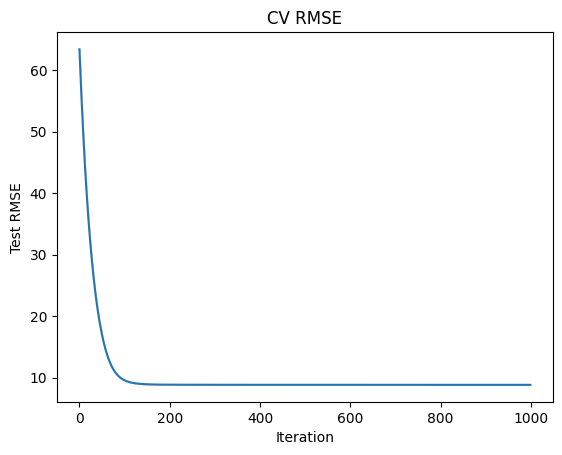

In [ ]:
plt.plot(cv_results['iterations'], cv_results['test-RMSE-mean'])
plt.fill_between(cv_results['iterations'],
                 cv_results['test-RMSE-mean'] - cv_results['test-RMSE-std'],
                 cv_results['test-RMSE-mean'] + cv_results['test-RMSE-std'],
                 alpha=0.2, color='red')
plt.xlabel('Iteration')
plt.ylabel('Test RMSE')
plt.title('CV RMSE')
plt.show()

In [ ]:
best_iteration = cv_results.loc[cv_results['train-RMSE-mean'].idxmin(), 'iterations']
params['iterations']= best_iteration
params['verbose'] = int(best_iteration // 10)

## Важность признаков

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data[num_features + cat_features], train_data['exam_score'],
    test_size=0.2, random_state=33, shuffle=True)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model = CatBoostRegressor(**params)
model.fit(train_pool)

Learning rate set to 0.102825
0:	learn: 17.6466508	total: 32.4ms	remaining: 26.5s
81:	learn: 8.8347622	total: 1.93s	remaining: 17.3s
162:	learn: 8.8108996	total: 3.75s	remaining: 15.1s
243:	learn: 8.7951930	total: 5.55s	remaining: 13.1s
324:	learn: 8.7829434	total: 7.35s	remaining: 11.2s
405:	learn: 8.7728219	total: 9.14s	remaining: 9.3s
486:	learn: 8.7631756	total: 12s	remaining: 8.19s
567:	learn: 8.7535707	total: 13.8s	remaining: 6.11s
648:	learn: 8.7454728	total: 15.6s	remaining: 4.09s
729:	learn: 8.7383215	total: 17.4s	remaining: 2.13s
810:	learn: 8.7312025	total: 19.3s	remaining: 190ms
818:	learn: 8.7306098	total: 19.4s	remaining: 0us


### Permutation

In [ ]:
fi = model.get_feature_importance(
    data=val_pool,
    type='LossFunctionChange',
)
pd.DataFrame({
    'feature': val_pool.get_feature_names(),
    'importance': fi
}).sort_values('importance', ascending=False)

,feature,importance
1,study_hours,7.299877
2,class_attendance,1.652836
5,sleep_quality,0.809654
8,study_method,0.660430
4,facility_rating,0.529412
3,sleep_hours,0.318779
7,course,0.000610
0,age,0.000381
9,gender,0.000266
10,internet_access,-0.000037


### Shap

In [ ]:
shap_vals = model.get_feature_importance(
    data=val_pool,
    type='ShapValues'
)

In [ ]:
shap = shap_vals[:, :-1]
global_importance = np.mean(np.abs(shap), axis=0)
pd.DataFrame({
    'feature': val_pool.get_feature_names(),
    'importance': global_importance
}).sort_values('importance', ascending=False)

,feature,importance
1,study_hours,11.662911
2,class_attendance,4.796564
5,sleep_quality,3.243199
8,study_method,3.065846
4,facility_rating,2.531380
3,sleep_hours,2.075542
0,age,0.137135
9,gender,0.126977
7,course,0.123071
6,exam_difficulty,0.034218


## Анализ ошибок

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

In [ ]:
y_pred = model.predict(val_pool)
print('r2', r2_score(y_val, y_pred))

r2 0.7842967166749075


### Scatter plot

Text(0, 0.5, 'predicted')

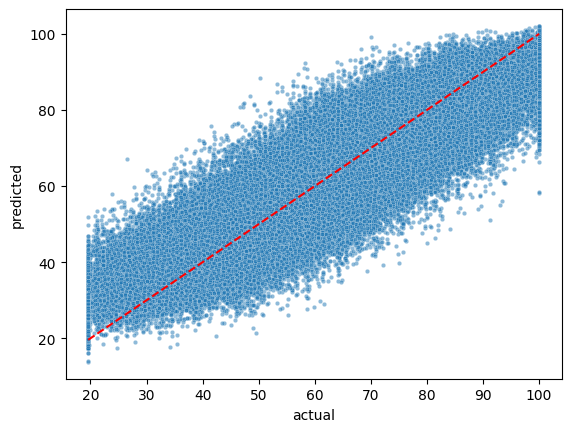

In [ ]:
sns.scatterplot(x=y_val, y=y_pred, s=10, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('actual')
plt.ylabel('predicted')

### Residuals

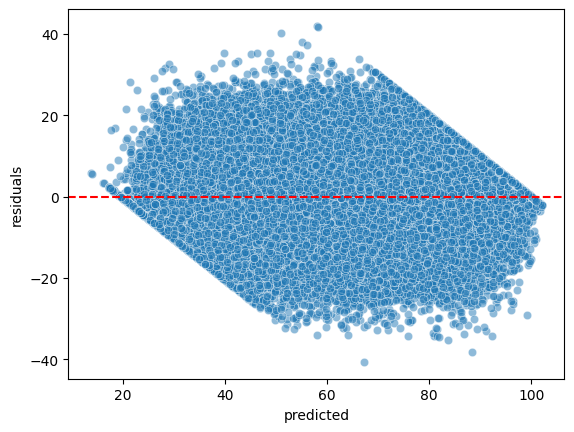

In [ ]:
residuals = y_val - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('predicted')
plt.ylabel('residuals')
plt.show()

### KDE ошибок

<Axes: xlabel='exam_score', ylabel='Count'>

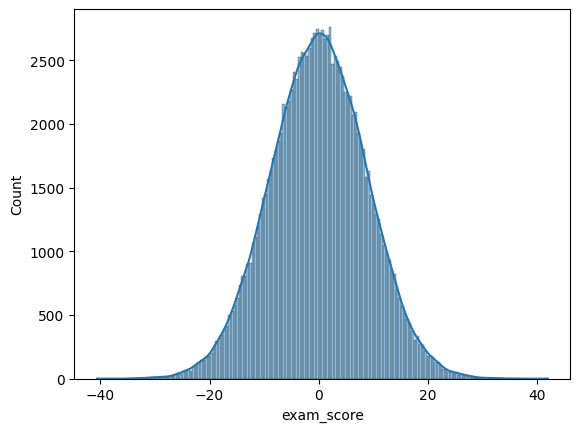

In [ ]:
sns.histplot(residuals, kde=True)

## Финальное обучение и сабмит

In [ ]:
train_pool = Pool(train_data[num_features + cat_features], train_data['exam_score'], cat_features=cat_features)
final_model = CatBoostRegressor(**params)
final_model.fit(train_pool)
test_pool = Pool(test_data[num_features+cat_features], cat_features=cat_features)
y_pred = final_model.predict(test_pool)
submission = pd.DataFrame({
    'id': test_data['id'],
    'exam_score': y_pred,
})
submission.to_csv('submission.csv', index=False)

Learning rate set to 0.103626
0:	learn: 17.6355478	total: 74ms	remaining: 1m 2s
84:	learn: 8.8301148	total: 3.23s	remaining: 29.1s
168:	learn: 8.8073638	total: 5.86s	remaining: 23.6s
252:	learn: 8.7925939	total: 8.51s	remaining: 20.1s
336:	learn: 8.7806913	total: 11.2s	remaining: 17.1s
420:	learn: 8.7710704	total: 14.7s	remaining: 14.9s
504:	learn: 8.7623658	total: 17.3s	remaining: 11.8s
588:	learn: 8.7548220	total: 20s	remaining: 8.81s
672:	learn: 8.7474571	total: 22.7s	remaining: 5.93s
756:	learn: 8.7410344	total: 26.2s	remaining: 3.19s
840:	learn: 8.7349282	total: 28.9s	remaining: 275ms
848:	learn: 8.7344216	total: 29.2s	remaining: 0us


In [ ]:
submission.head()

,id,exam_score
0,630000,71.724972
1,630001,70.106819
2,630002,88.409052
3,630003,56.861953
4,630004,47.266841


In [ ]:
!kaggle competitions submit -c playground-series-s6e1 -f submission.csv -m "Without exam_difficulty + ordinal encoding of some features"

100% 6.45M/6.45M [00:00<00:00, 9.38MB/s]
Successfully submitted to Predicting Student Test Scores

##

# Выводы и гипотезы

Делаю по очереди

1. Сделать cat_features порядковыми: course (полагается градация курсов от младшего к старшему), exam_dificulity, sleep_quality (да, он хоть и по важности норм, но я думаю, что модель должна его адекватнее воспринимать).
2. Удалю gender, ибо он по всем feature importance лажа (точнее если он и после пункта 6 будет лажой), ну и по сути - гендер не влияет на успеваемость будь ты male female или даже other...
3. internet_access можно не убирать пока что, потому что возможно модель его не очень воспринимает из-за плохих других фич (посмотрим по пред пунктам)

## Сделать cat_features порядковыми

Лосс почему-то даже ухудшился.

Смотрим по permutation importance
sleep quality улучшил свой вклад
facility rating улучшил свой вклад
course ухудшил - видно лучше его оставить категориальным
exam_difficulty вообще непонятный - признак же огонь, что же он так плохо работает

По shap все осталось примерно также ну плюс минус (в целом сейчас важнее permutation)

остальные нетронутые признаки улучшили свой вклад или остались нейтральными кроме  sleep_hours (но в целом этот признак коррелирует я думаю с sleep quality и по идее их можно объединить или оставить как есть хз)

gender по прежнему мне кажется лишним
internet_access тоже начинает казаться лишним

Итого:



1. exam_difficulty - странный признак, вроде бы должен решать, но на деле ухудшает, я не хочу его удалять до рассмотрения
2. в целом насчет sleep_hours и sleep_quality можно не париться - пусть будет 2 признака, ну мб попробую объединить, но это не приоритет

3. exam_difficulty важен статистически, но по permutation importance дает ухудшение. По идее если умножить ранжировку course на ранжировку exam_difficulity я думаю можно что-то улучшить. Но сначала я попробую удалить этот признак.

4. короче после точечных экспериментов я вывел что exam_difficulty мешает, а course лучше оставить в исходном виде



#### Эксперимент улучшил на сабмит на 0.001 - я доволен

## Убрать gender

Ухудшило сабмит. Оставим.

## Internet access

internet_access тоже самое что и exam_difficulty - видимо сам бустинг не может воспринять эту фичу адекватно, поэтому конкретно в этом кейсе internet_access лучше убрать.

Убрал - в целом это ничего не дало ни ухудшения ни улучшения.


В целом появилась мысль, что возможно CatBoost тут излишен и надо было бы сначала проверить линейность сигнала - может тут гораздо эффективнее будет линейная модель или небольшая MLP.

## Итоги feature engineering

Сам mapping улучшает качество ненамного, но все-таки.
В целом я думаю, что то, что internet access, exam_difficulty плохо влияют на обучение - проблема не в самих признаках, а в том, что Catboost довольно сложная модель и переобучается.
Поэтому этой модели нужно подкрутить множество гиперпараметров, в т.ч. регуляризацию, глубину и прочее, но изначально я бы хотел запустить простейшую линейную регрессию в третьем блокноте, чтобы просто сравнить.

# Поток

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

In [ ]:
train_data['internet_access'] = train_data['internet_access'].map({'no': 0, 'yes': 1})

In [ ]:
group0 = train_data[train_data['internet_access'] == 0]['exam_score']
group1 = train_data[train_data['internet_access'] == 1]['exam_score']
stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
print(f'U-statistc={stat}, p-val={p_value}')

if p_value < 0.05:
    print('internet access влияет на score')
else:
    print('internet access не влияет')

U-statistc=14565777034.5, p-val=0.026619286363380026
internet access влияет на score


<Axes: xlabel='internet_access', ylabel='exam_score'>

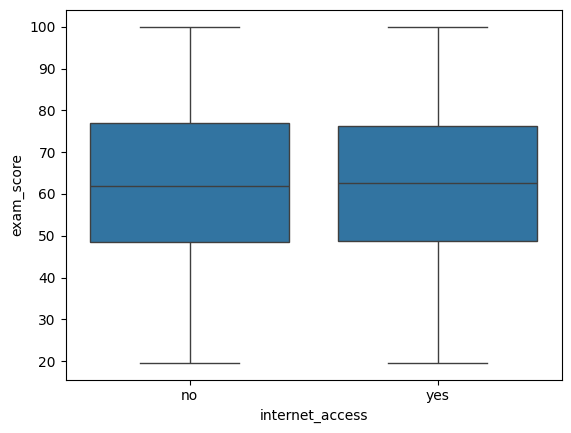

In [ ]:
sns.boxplot(x='internet_access', y='exam_score', data=train_data)

In [ ]:


groups = [
    train_data[train_data['exam_difficulty'] == cat]['exam_score']
    for cat in train_data['exam_difficulty'].unique()
]

h_stat, p_value = kruskal(*groups)
print(f"H-statistic={h_stat}, p-value={p_value}")
if p_value < 0.05:
    print("сложность влияет на score")
else:
    print("сложность не влияет на Score")


H-statistic=53.95364347196037, p-value=1.9236018265109947e-12
Фича значимо влияет на таргет (отвергаем H0)


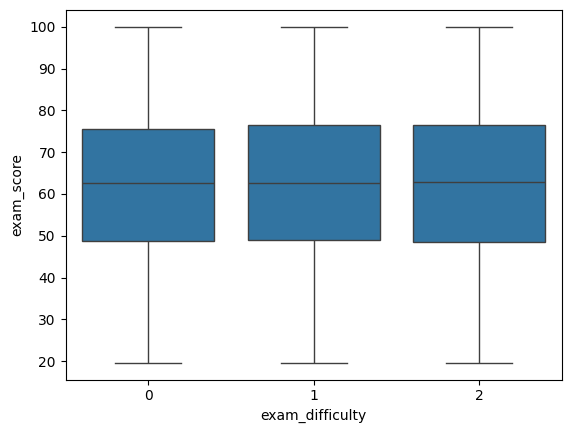

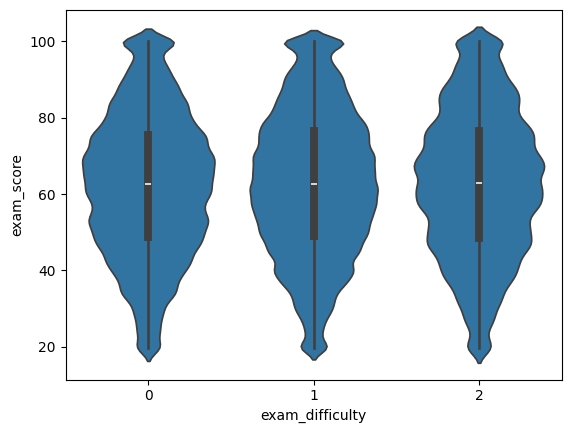

In [ ]:
sns.boxplot(x='exam_difficulty', y='exam_score', data=train_data)
plt.show()

# или для более гладкой визуализации
sns.violinplot(x='exam_difficulty', y='exam_score', data=train_data)
plt.show()


In [ ]:
train_data['exam_difficulty'].unique()

array(['easy', 'moderate', 'hard'], dtype=object)

In [ ]:
train_data['sleep_quality'].unique()

array(['average', 'poor', 'good'], dtype=object)

In [ ]:
train_data['course'].unique()

array(['b.sc', 'diploma', 'bca', 'b.com', 'ba', 'bba', 'b.tech'],
      dtype=object)

,exam_difficulty
0,easy
1,moderate
2,moderate
3,moderate
4,easy
...,...
629995,moderate
629996,moderate
629997,moderate
629998,moderate
